In [90]:
# !pip install pandas openpyxl matplotlib
! pip install plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

 

In [92]:
!pip install plotly
import plotly.express as px

In [96]:
!pip install -U kaleido


   ---------------------------------------- 0/6 [simplejson]
   ---------------------------------------- 0/6 [simplejson]
   ---------------------------------------- 0/6 [simplejson]
   ---------------------------------------- 0/6 [simplejson]
   ---------------------------------------- 0/6 [simplejson]
   ------ --------------------------------- 1/6 [orjson]
   ------------- -------------------------- 2/6 [logistro]
   -------------------------- ------------- 4/6 [choreographer]
   -------------------------- ------------- 4/6 [choreographer]
   -------------------------- ------------- 4/6 [choreographer]
   -------------------------- ------------- 4/6 [choreographer]
   -------------------------- ------------- 4/6 [choreographer]
   -------------------------- ------------- 4/6 [choreographer]
   --------------------------------- ------ 5/6 [kaleido]
   --------------------------------- ------ 5/6 [kaleido]
   --------------------------------- ------ 5/6 [kaleido]
   -----------------

In [61]:
# === SETTINGS ===
INPUT_XLSX = "USA1.xlsx"
OUTPUT_XLSX = "USA_ranked1.xlsx"
STATE_COL = "State"


In [62]:
# Show all rows and columns temporarily
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df)

,State,Average used car price(iSeeCars),Sales_Tax_pct(Policygenius),Doc_Fee_USD(CarEdge),Registration_USD(WorldPopulationReview),Insurance_USD(bankrate),Total_Fees_USD,Total_Fees_20k_USD,Total_Fees_pct,Rank_Used,Rank_Tax,Rank_Ins,Rank_Reg,Rank_Doc,Weighted_Score,Final_Rank,Used_Norm,Tax_Norm,Ins_Norm,Reg_Norm,Doc_Norm
0,Alabama,34206,2.00,489,67.00,2056,1240.1200,956.00,3.625446,23,6,16,35,34,19.32,11,0.277209,0.242424,0.236862,0.363484,0.442013
1,Alaska,40462,0.00,299,100.00,2488,399.0000,399.00,0.986110,49,1,31,43,16,29.14,37,0.905321,0.000000,0.403787,0.584590,0.234136
2,Arizona,34413,5.60,499,40.00,2367,2466.1280,1659.00,7.166269,24,25,27,19,35,25.28,26,0.297992,0.678788,0.357032,0.182580,0.452954
3,Arkansas,36343,6.50,129,24.00,2444,2515.2950,1453.00,6.920989,44,38,29,7,4,31.11,40,0.491767,0.787879,0.386785,0.075377,0.048140
4,California,35759,7.25,85,64.00,3102,2741.5275,1599.00,7.666678,40,48,44,34,1,39.16,50,0.433133,0.878788,0.641036,0.343384,0.000000
5,Colorado,35269,2.90,699,100.00,3233,1821.8010,1379.00,5.165446,35,7,46,43,47,32.67,43,0.383936,0.351515,0.691654,0.584590,0.671772
6,Connecticut,32991,6.35,599,40.00,2715,2733.9285,1909.00,8.286892,8,37,37,19,43,26.62,28,0.155221,0.769697,0.491499,0.182580,0.562363
7,Delaware,32924,0.00,475,40.00,2931,515.0000,515.00,1.564208,6,1,40,19,33,16.97,7,0.148494,0.000000,0.574961,0.182580,0.426696
8,Florida,34519,6.00,999,23.50,3874,3093.6400,2222.50,8.962137,25,27,48,6,50,30.97,39,0.308635,0.727273,0.939335,0.072027,1.000000
9,Georgia,36016,7.00,599,20.00,2895,3140.1200,2019.00,8.718681,42,44,39,2,43,37.03,47,0.458936,0.848485,0.561051,0.048576,0.562363


In [63]:
INPUT_XLSX

'USA1.xlsx'

In [64]:
cols_expected = {
    "price": "Average used car price(iSeeCars)",
    "sales_tax_pct": "Sales_Tax_pct(Policygenius)",
    "doc_fee": "Doc_Fee_USD(CarEdge)",
    "registration": "Registration_USD(WorldPopulationReview)",
    "insurance": "Insurance_USD(bankrate)",
}

In [65]:
# Load & sort alphabetically
df = pd.read_excel(INPUT_XLSX)
df = df.sort_values(by=STATE_COL).reset_index(drop=True)

In [66]:
# Convert numeric columns safely
for cname in cols_expected.values():
    if cname not in df.columns:
        raise ValueError(f"Missing expected column: {cname}")
    df[cname] = pd.to_numeric(df[cname], errors="coerce")

In [67]:
# Report missing values
print("Missing values per column:\n", df.isna().sum())

Missing values per column:
 State                                      0
Average used car price(iSeeCars)           0
Sales_Tax_pct(Policygenius)                0
Doc_Fee_USD(CarEdge)                       0
Registration_USD(WorldPopulationReview)    0
Insurance_USD(bankrate)                    0
dtype: int64


In [68]:
# Compute fees
df["Total_Fees_USD"] = (
    df[cols_expected["doc_fee"]].fillna(0) +
    df[cols_expected["registration"]].fillna(0) +
    (df[cols_expected["sales_tax_pct"]].fillna(0) / 100.0) *
    df[cols_expected["price"]].fillna(0)
)

In [69]:
df["Total_Fees_20k_USD"] = (
    df[cols_expected["doc_fee"]].fillna(0) +
    df[cols_expected["registration"]].fillna(0) +
    (df[cols_expected["sales_tax_pct"]].fillna(0) / 100.0) * 20000
)

In [70]:
df["Total_Fees_pct"] = np.where(
    df[cols_expected["price"]].notna(),
    df["Total_Fees_USD"] / df[cols_expected["price"]] * 100.0,
    np.nan
)


In [71]:
# Rank each metric (1 = best/lowest)
df["Rank_Used"] = df[cols_expected["price"]].rank(method="min", ascending=True)
df["Rank_Tax"] = df[cols_expected["sales_tax_pct"]].rank(method="min", ascending=True)
df["Rank_Ins"] = df[cols_expected["insurance"]].rank(method="min", ascending=True)
df["Rank_Reg"] = df[cols_expected["registration"]].rank(method="min", ascending=True)
df["Rank_Doc"] = df[cols_expected["doc_fee"]].rank(method="min", ascending=True)


In [72]:
for c in ["Rank_Used","Rank_Tax","Rank_Ins","Rank_Reg","Rank_Doc"]:
    df[c] = df[c].astype('Int64')


In [73]:
w_used, w_tax, w_ins, w_reg, w_doc = 0.30, 0.25, 0.25, 0.12, 0.08
df["Weighted_Score"] = (
    w_used*df["Rank_Used"].astype(float) +
    w_tax*df["Rank_Tax"].astype(float) +
    w_ins*df["Rank_Ins"].astype(float) +
    w_reg*df["Rank_Reg"].astype(float) +
    w_doc*df["Rank_Doc"].astype(float)
)
df["Final_Rank"] = df["Weighted_Score"].rank(method="min", ascending=True).astype('Int64')


In [74]:
# --- Normalized 0-1 scores (lower is better) ---
df["Used_Norm"] = (df[cols_expected["price"]] - df[cols_expected["price"]].min()) / (df[cols_expected["price"]].max() - df[cols_expected["price"]].min())
df["Tax_Norm"] = (df[cols_expected["sales_tax_pct"]] - df[cols_expected["sales_tax_pct"]].min()) / (df[cols_expected["sales_tax_pct"]].max() - df[cols_expected["sales_tax_pct"]].min())
df["Ins_Norm"] = (df[cols_expected["insurance"]] - df[cols_expected["insurance"]].min()) / (df[cols_expected["insurance"]].max() - df[cols_expected["insurance"]].min())
df["Reg_Norm"] = (df[cols_expected["registration"]] - df[cols_expected["registration"]].min()) / (df[cols_expected["registration"]].max() - df[cols_expected["registration"]].min())
df["Doc_Norm"] = (df[cols_expected["doc_fee"]] - df[cols_expected["doc_fee"]].min()) / (df[cols_expected["doc_fee"]].max() - df[cols_expected["doc_fee"]].min())

In [75]:
# Save and quick outputs
df.to_excel(OUTPUT_XLSX, index=False)
print(f"Saved results to {OUTPUT_XLSX}")

Saved results to USA_ranked1.xlsx


In [76]:
top_10 = df.nsmallest(10, "Final_Rank")[[STATE_COL, "Final_Rank", "Weighted_Score"]]
print("\nTop 10 Best States to Buy a Used Car:")
print(top_10)


Top 10 Best States to Buy a Used Car:
             State  Final_Rank  Weighted_Score
28   New Hampshire           1            6.70
34            Ohio           2           12.05
44         Vermont           3           12.67
10          Hawaii           4           13.77
13         Indiana           5           15.84
18           Maine           6           15.90
7         Delaware           7           16.97
32  North Carolina           8           18.70
45        Virginia           9           18.85
23     Mississippi          10           19.16


In [77]:
bottom_10 = df.nlargest(10, "Final_Rank")[[STATE_COL, "Final_Rank", "Weighted_Score"]]
print("\nBottom 10 States:")
print(bottom_10)


Bottom 10 States:
         State  Final_Rank  Weighted_Score
4   California          50           39.16
12    Illinois          49           38.08
27      Nevada          48           37.31
9      Georgia          47           37.03
29  New Jersey          46           34.34
17   Louisiana          45           34.27
15      Kansas          44           33.60
5     Colorado          43           32.67
35    Oklahoma          42           31.33
42       Texas          41           31.17


In [78]:
avg_price = df[cols_expected["price"]].mean()
lowest_fees_state = df.loc[df["Total_Fees_USD"].idxmin(), STATE_COL]

print(f"\nAverage used car price across US: ${avg_price:,.2f}")
print(f"State with lowest total fees: {lowest_fees_state}")


Average used car price across US: $34,777.64
State with lowest total fees: Oregon


In [84]:
# --- STATISTICAL SUMMARY ---
numeric_cols = [
    cols_expected["price"],
    cols_expected["sales_tax_pct"],
    cols_expected["doc_fee"],
    cols_expected["registration"],
    cols_expected["insurance"],
    "Total_Fees_USD",
    "Total_Fees_20k_USD",
    "Weighted_Score"
]

print("\n--- Statistical Summary ---")
stats = df[numeric_cols].describe().T  # Transposed for readability
stats["median"] = df[numeric_cols].median()
stats["variance"] = df[numeric_cols].var()
print(stats)


--- Statistical Summary ---
                                         count        mean          std  \
Average used car price(iSeeCars)          50.0  34777.6400  1968.774246   
Sales_Tax_pct(Policygenius)               50.0      4.9858     2.112893   
Doc_Fee_USD(CarEdge)                      50.0    395.9600   192.692942   
Registration_USD(WorldPopulationReview)   50.0     58.6310    37.000532   
Insurance_USD(bankrate)                   50.0   2413.6600   632.744092   
Total_Fees_USD                            50.0   2178.6895   726.762722   
Total_Fees_20k_USD                        50.0   1451.7510   439.215027   
Weighted_Score                            50.0     25.0596     7.206751   

                                              min          25%        50%  \
Average used car price(iSeeCars)         31445.00  33596.25000  34549.500   
Sales_Tax_pct(Policygenius)                  0.00      4.03750      5.675   
Doc_Fee_USD(CarEdge)                        85.00    250.00000  

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11432\1534398621.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x="Weighted_Score", y=STATE_COL, palette="crest")


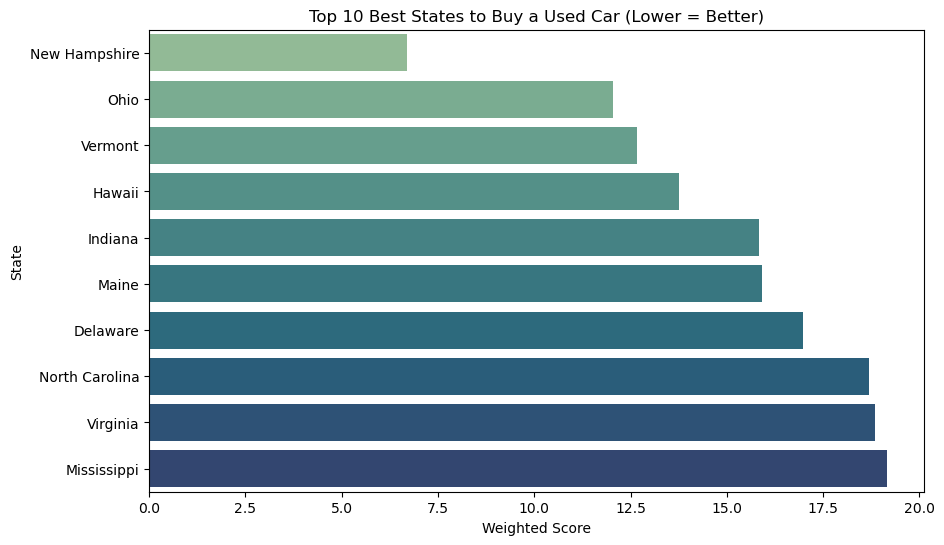

In [80]:
# --- Visualizations ---
plt.figure(figsize=(10,6))
sns.barplot(data=top_10, x="Weighted_Score", y=STATE_COL, palette="crest")
plt.title("Top 10 Best States to Buy a Used Car (Lower = Better)")
plt.xlabel("Weighted Score")
plt.ylabel("State")
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11432\1368941696.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_10, x="Weighted_Score", y=STATE_COL, palette="rocket")


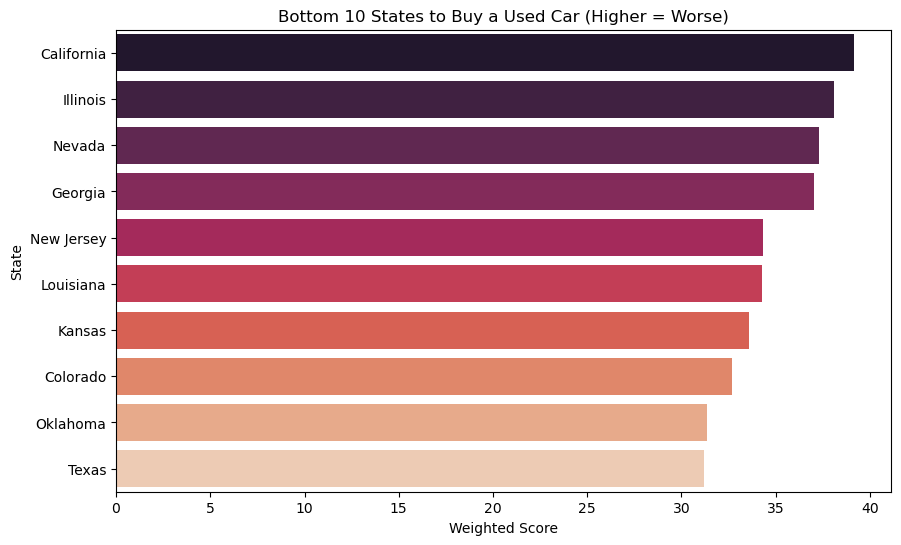

In [81]:
plt.figure(figsize=(10,6))
sns.barplot(data=bottom_10, x="Weighted_Score", y=STATE_COL, palette="rocket")
plt.title("Bottom 10 States to Buy a Used Car (Higher = Worse)")
plt.xlabel("Weighted Score")
plt.ylabel("State")
plt.show()

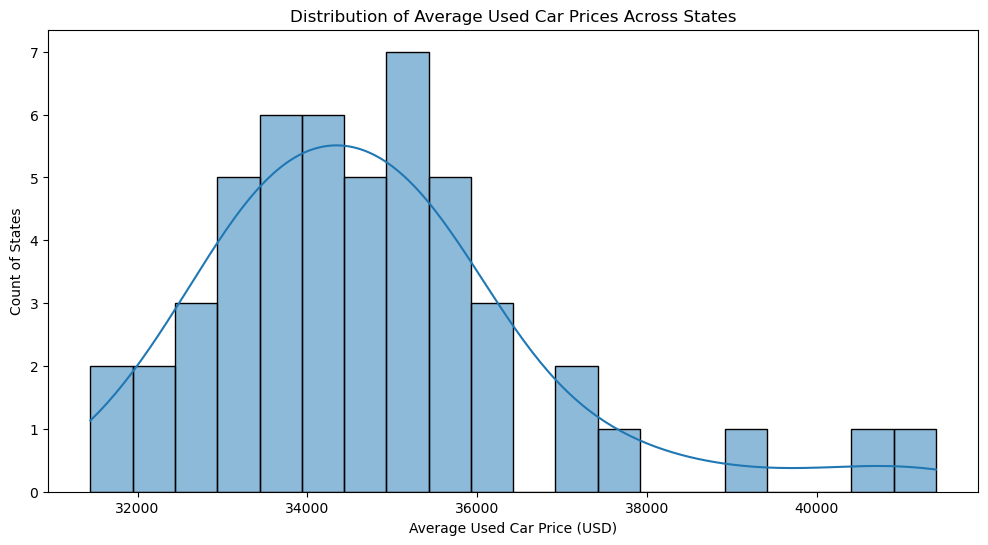

In [82]:
plt.figure(figsize=(12,6))
sns.histplot(df[cols_expected["price"]], bins=20, kde=True)
plt.title("Distribution of Average Used Car Prices Across States")
plt.xlabel("Average Used Car Price (USD)")
plt.ylabel("Count of States")
plt.show()

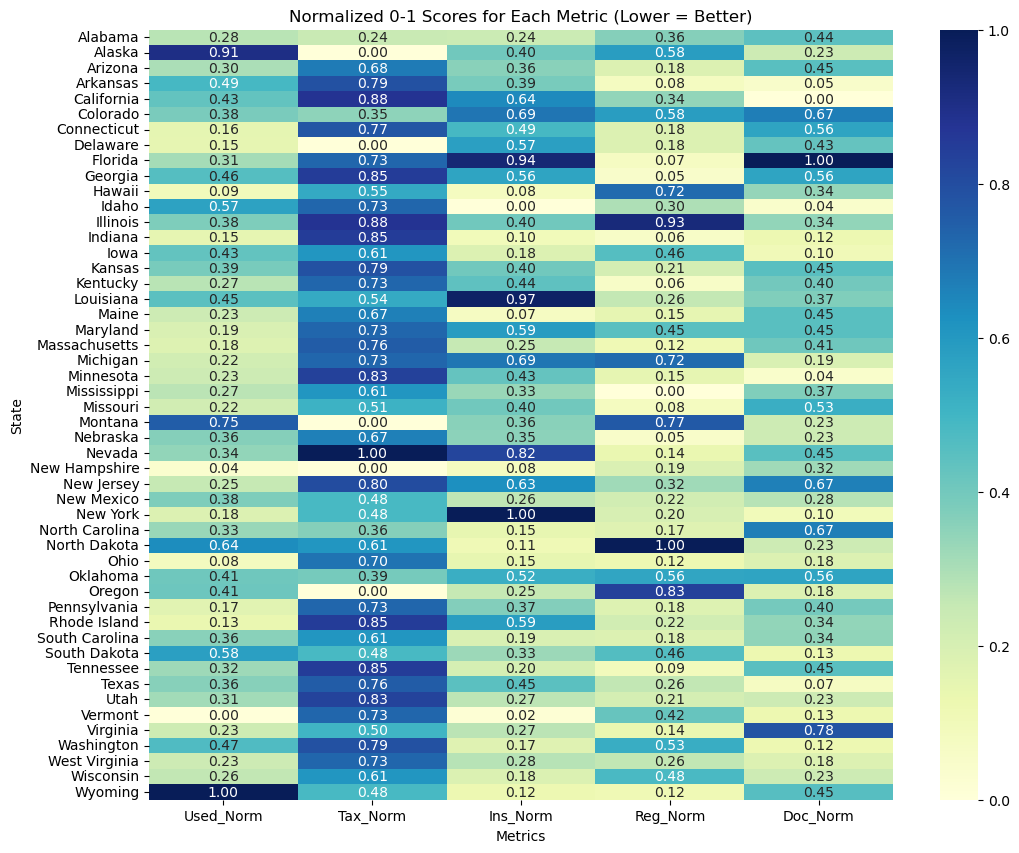

In [83]:
# Heatmap of normalized metrics for all states
norm_cols = ["Used_Norm", "Tax_Norm", "Ins_Norm", "Reg_Norm", "Doc_Norm"]
plt.figure(figsize=(12,10))
sns.heatmap(df[norm_cols].set_index(df[STATE_COL]), cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Normalized 0-1 Scores for Each Metric (Lower = Better)")
plt.xlabel("Metrics")
plt.ylabel("State")
plt.show()